In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv")

In [4]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.drop(columns = ['Serial No.'] , inplace = True)

In [11]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [12]:
df.shape

(500, 8)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [16]:
X = df.drop(columns = ['Chance of Admit '])
y = df['Chance of Admit '].values

In [17]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [18]:
y

array([0.92, 0.76, 0.72, 0.8 , 0.65, 0.9 , 0.75, 0.68, 0.5 , 0.45, 0.52,
       0.84, 0.78, 0.62, 0.61, 0.54, 0.66, 0.65, 0.63, 0.62, 0.64, 0.7 ,
       0.94, 0.95, 0.97, 0.94, 0.76, 0.44, 0.46, 0.54, 0.65, 0.74, 0.91,
       0.9 , 0.94, 0.88, 0.64, 0.58, 0.52, 0.48, 0.46, 0.49, 0.53, 0.87,
       0.91, 0.88, 0.86, 0.89, 0.82, 0.78, 0.76, 0.56, 0.78, 0.72, 0.7 ,
       0.64, 0.64, 0.46, 0.36, 0.42, 0.48, 0.47, 0.54, 0.56, 0.52, 0.55,
       0.61, 0.57, 0.68, 0.78, 0.94, 0.96, 0.93, 0.84, 0.74, 0.72, 0.74,
       0.64, 0.44, 0.46, 0.5 , 0.96, 0.92, 0.92, 0.94, 0.76, 0.72, 0.66,
       0.64, 0.74, 0.64, 0.38, 0.34, 0.44, 0.36, 0.42, 0.48, 0.86, 0.9 ,
       0.79, 0.71, 0.64, 0.62, 0.57, 0.74, 0.69, 0.87, 0.91, 0.93, 0.68,
       0.61, 0.69, 0.62, 0.72, 0.59, 0.66, 0.56, 0.45, 0.47, 0.71, 0.94,
       0.94, 0.57, 0.61, 0.57, 0.64, 0.85, 0.78, 0.84, 0.92, 0.96, 0.77,
       0.71, 0.79, 0.89, 0.82, 0.76, 0.71, 0.8 , 0.78, 0.84, 0.9 , 0.92,
       0.97, 0.8 , 0.81, 0.75, 0.83, 0.96, 0.79, 0.

In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.2 , random_state = 1)

In [21]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
238,310,104,3,2.0,3.5,8.37,0
438,318,110,1,2.5,3.5,8.54,1
475,300,101,3,3.5,2.5,7.88,0
58,300,99,1,3.0,2.0,6.80,1
380,322,104,3,3.5,4.0,8.84,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [22]:
X_test

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
304,313,106,2,2.5,2.0,8.43,0
340,312,107,3,3.0,3.0,8.46,1
47,339,119,5,4.5,4.0,9.70,0
67,316,107,2,3.5,3.5,8.64,1
479,325,110,4,4.5,4.0,8.96,1
...,...,...,...,...,...,...,...
11,327,111,4,4.0,4.5,9.00,1
192,322,114,5,4.5,4.0,8.94,1
92,298,98,2,4.0,3.0,8.03,0
221,316,110,3,3.5,4.0,8.56,0


In [23]:
y_train

array([0.7 , 0.67, 0.59, 0.36, 0.78, 0.44, 0.71, 0.71, 0.66, 0.64, 0.47,
       0.84, 0.94, 0.76, 0.76, 0.71, 0.58, 0.63, 0.46, 0.77, 0.86, 0.49,
       0.52, 0.92, 0.71, 0.58, 0.96, 0.79, 0.5 , 0.86, 0.51, 0.44, 0.93,
       0.96, 0.95, 0.81, 0.89, 0.71, 0.38, 0.61, 0.78, 0.87, 0.69, 0.56,
       0.69, 0.73, 0.73, 0.42, 0.57, 0.95, 0.62, 0.47, 0.9 , 0.48, 0.85,
       0.77, 0.7 , 0.86, 0.9 , 0.56, 0.63, 0.73, 0.34, 0.8 , 0.71, 0.71,
       0.78, 0.92, 0.69, 0.83, 0.44, 0.74, 0.49, 0.84, 0.89, 0.89, 0.53,
       0.78, 0.84, 0.38, 0.72, 0.42, 0.56, 0.64, 0.72, 0.58, 0.42, 0.94,
       0.78, 0.46, 0.67, 0.85, 0.84, 0.66, 0.65, 0.77, 0.84, 0.73, 0.73,
       0.58, 0.79, 0.84, 0.59, 0.64, 0.64, 0.62, 0.77, 0.57, 0.87, 0.72,
       0.87, 0.61, 0.91, 0.81, 0.61, 0.8 , 0.69, 0.56, 0.62, 0.45, 0.62,
       0.66, 0.69, 0.92, 0.62, 0.69, 0.78, 0.63, 0.83, 0.71, 0.91, 0.94,
       0.75, 0.49, 0.79, 0.52, 0.93, 0.61, 0.59, 0.68, 0.64, 0.72, 0.63,
       0.93, 0.82, 0.87, 0.81, 0.52, 0.71, 0.9 , 0.

In [24]:
y_test

array([0.62, 0.75, 0.89, 0.57, 0.79, 0.7 , 0.76, 0.74, 0.77, 0.64, 0.72,
       0.64, 0.71, 0.61, 0.74, 0.88, 0.64, 0.79, 0.92, 0.75, 0.64, 0.78,
       0.84, 0.53, 0.55, 0.39, 0.94, 0.58, 0.89, 0.72, 0.73, 0.79, 0.64,
       0.92, 0.49, 0.84, 0.7 , 0.65, 0.66, 0.93, 0.63, 0.74, 0.78, 0.96,
       0.8 , 0.43, 0.68, 0.65, 0.61, 0.62, 0.81, 0.94, 0.9 , 0.58, 0.79,
       0.54, 0.73, 0.62, 0.65, 0.74, 0.42, 0.76, 0.78, 0.86, 0.96, 0.65,
       0.76, 0.81, 0.94, 0.67, 0.62, 0.67, 0.83, 0.54, 0.91, 0.57, 0.87,
       0.92, 0.74, 0.82, 0.87, 0.45, 0.93, 0.76, 0.78, 0.71, 0.92, 0.93,
       0.54, 0.62, 0.65, 0.8 , 0.52, 0.75, 0.73, 0.84, 0.86, 0.34, 0.75,
       0.61])

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [27]:
X_train_scaled

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]])

In [28]:
X_test_scaled

array([[0.46      , 0.48      , 0.25      , 0.375     , 0.25      ,
        0.44140625, 0.        ],
       [0.44      , 0.52      , 0.5       , 0.5       , 0.5       ,
        0.453125  , 1.        ],
       [0.98      , 1.        , 1.        , 0.875     , 0.75      ,
        0.9375    , 0.        ],
       [0.52      , 0.52      , 0.25      , 0.625     , 0.625     ,
        0.5234375 , 1.        ],
       [0.7       , 0.64      , 0.75      , 0.875     , 0.75      ,
        0.6484375 , 1.        ],
       [0.42      , 0.28      , 0.25      , 0.375     , 0.625     ,
        0.40625   , 1.        ],
       [0.6       , 0.4       , 0.5       , 0.5       , 0.625     ,
        0.5625    , 1.        ],
       [0.74      , 0.36      , 0.5       , 0.75      , 0.75      ,
        0.390625  , 1.        ],
       [0.62      , 0.68      , 0.5       , 0.625     , 0.75      ,
        0.59765625, 1.        ],
       [0.56      , 0.48      , 0.25      , 0.75      , 0.75      ,
        0.2421875 , 1. 

In [30]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [32]:
model = Sequential()

model.add(Dense(7 , activation = 'relu' , input_dim = 7))
model.add(Dense(7 , activation = 'relu'))
model.add(Dense(1 , activation = 'sigmoid'))

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer = 'Adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [36]:
history = model.fit(X_train_scaled , y_train , batch_size = 50 , epochs = 100 , verbose= 1 , validation_split = 0.2)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.0000e+00 - loss: 0.6567 - val_accuracy: 0.0000e+00 - val_loss: 0.6458
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.6485 - val_accuracy: 0.0000e+00 - val_loss: 0.6368
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.6411 - val_accuracy: 0.0000e+00 - val_loss: 0.6284
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.6340 - val_accuracy: 0.0000e+00 - val_loss: 0.6200
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: 0.6273 - val_accuracy: 0.0000e+00 - val_loss: 0.6115
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.6203 - val_accuracy: 0.0000e+00 - val_loss: 0.6033
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: 0.6137 - val_accuracy: 0.0000e+00 - val_loss: 0.5950
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 

In [37]:
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [41]:
from sklearn.metrics import r2_score
r2_score(y_test , y_pred)

0.7321764219422788

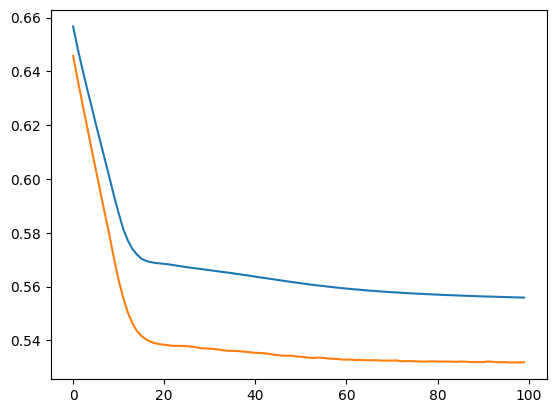

In [42]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])